In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from typing import Any
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE=True
except ImportError:
    PLOTLY_AVAILABLE=False
    print('Plotly is not installed. Interactive graphs will not be available.')
    print('Install plotly: pip install plotly')
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    STATSMODELS_AVAILABLE=True
except ImportError:
    STATSMODELS_AVAILABLE=False
    print('Statsmodels is not installed. Seasonal decomposition will not be available.')
    print('Install statsmodels:pip install statsmodels') 

warnings.filterwarnings('ignore')

#display settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('Libraries succesfully imported!')

Libraries succesfully imported!


In [3]:
# PHASE 1 - Data preparation and loading

df=pd.read_csv('sales_data.csv', encoding='utf-8-sig')
print(f'Loaded {len(df)} rows of data.')
print(f'Number of columns is {len(df.columns)}.')

print('First 5 rows.')
print(df.head())
print('\n'+ '='*50+'\n')
print('Data information:')
print(df.info())
print('\n'+ '='*50+'\n')
print('Basic statistics:')
print(df.describe())

# checking for missing values
missing_values=df.isnull().sum()
print('missing values by column.')
print(missing_values)
print('\n'+ '='*50+'\n')

if missing_values.sum()>0:
    print('There are missing values that need to be processed.')
    df=df.dropna()
    print(f'After removing missing values: {len(df)} rows')
else: 
    print('No missing values!')

# checking up for duplicates
duplicates=df.duplicated().sum()
print(f'Number of duplicates: {duplicates}')
if duplicates>0:
    df=df.drop_duplicates()
    print(f'After removing duplicates {len(df)} rows.')
else:
    print('No duplicates visible!')

# data type conversion
df['Date']=pd.to_datetime(df['Date'])
print('Data types:')
print(df.dtypes)
print('\n'+ '='*50+'\n')
print('Data is sucessfully converted!')

# creating additional columns
df['Profit']=df['Total_value']-df['Costs']
df['Month']=df['Date'].dt.month
df['Quarter']=df['Date'].dt.quarter
df['Year']=df['Date'].dt.year
df['Month_Year']=df['Date'].dt.to_period('M')
df['Profit_Margin']=(df['Profit']/df['Total_value'])*100
df['Profit_Margin']=df['Profit_Margin'].round(2)
print('Additional column is sucessfully created.')
print('\n Overview of new columns:')
print(df[['Date', 'Month', 'Quarter', 'Year', 'Profit', 'Profit_Margin']].head())

Loaded 5000 rows of data.
Number of columns is 8.
First 5 rows.
         Date    Product     Category  Quantity  Price_per_unit  Total_value  \
0  2023-01-01      Mouse  Peripherals         5              99          495   
1  2023-01-01      Mouse  Peripherals         4              59          236   
2  2023-01-01  Processor   Components         3             405         1215   
3  2023-01-01  USB drive    Equipment         2              38           76   
4  2023-01-01       Case   Components         9             132         1188   

        Region  Costs  
0  Los Angeles    305  
1      Chicago    156  
2      Phoenix    834  
3      Houston     50  
4      Chicago    720  


Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            5000 non-null   object
 1   Product         5000 non-null   object
 2   Cate

Basic statistics for numeric columns:
          Quantity  Price_per_unit   Total_value         Costs       Profit  \
count  5000.000000      5000.00000   5000.000000   5000.000000  5000.000000   
mean      5.505800       334.16980   1826.855800   1184.390400   642.465400   
std       2.831673       375.26915   2447.487801   1589.648804   864.696692   
min       1.000000        10.00000     16.000000      9.000000     7.000000   
25%       3.000000        99.00000    408.000000    264.000000   144.000000   
50%       6.000000       184.00000    934.000000    598.500000   329.000000   
75%       8.000000       405.00000   2136.000000   1368.000000   740.000000   
max      10.000000      1997.00000  19610.000000  12480.000000  7130.000000   

       Profit_Margin  
count    5000.000000  
mean       35.390396  
std         2.953646  
min        30.040000  
25%        32.880000  
50%        35.315000  
75%        37.930000  
max        46.150000  


Total_values:
Total sales: 9,134,279
Tota

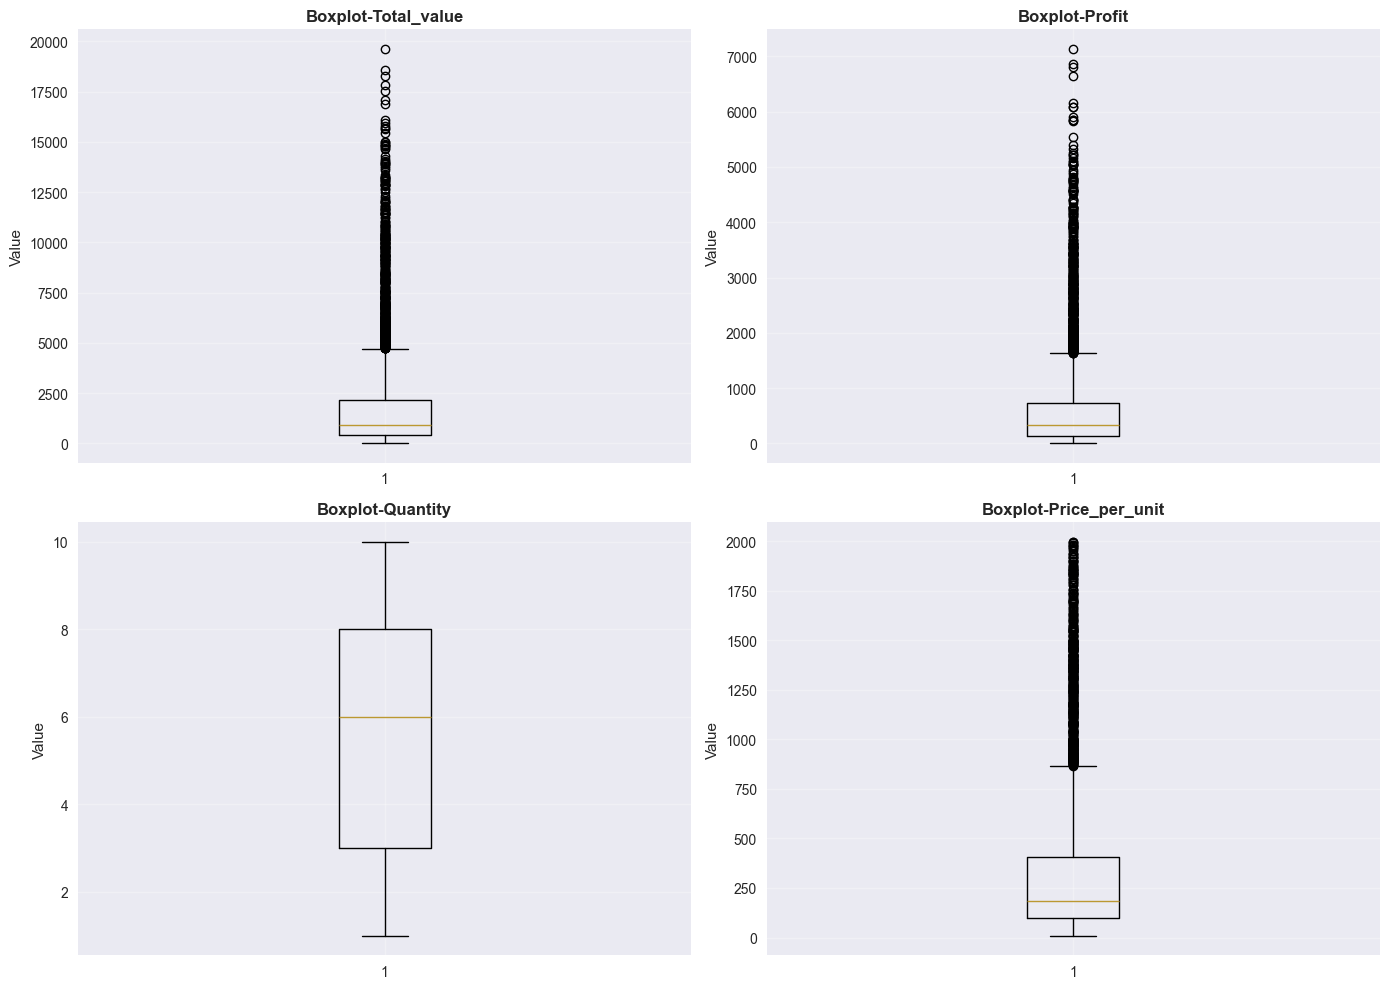

Outlier analysis saved as: outlier_analysis.png
DISTRIBUTION ANALYSIS:


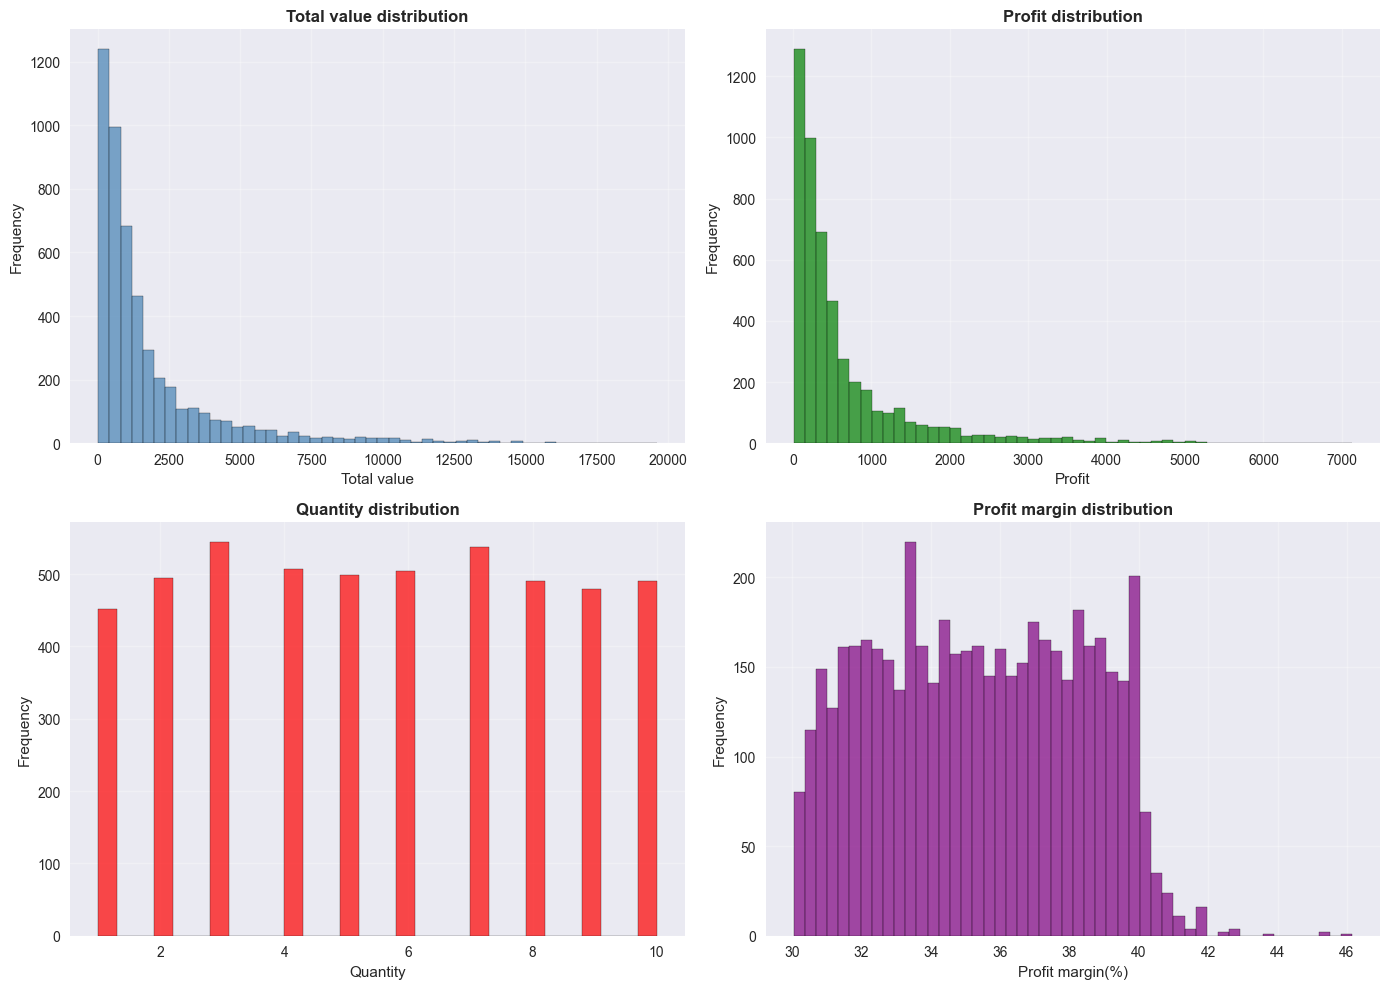

Distribution analysis saved as: distribution_analysis.png


In [4]:
# PHASE 2 - Exploratory data analysis
# Basic statistics
print('Basic statistics for numeric columns:')
print(df[['Quantity', 'Price_per_unit', 'Total_value', 'Costs', 'Profit', 'Profit_Margin']].describe())
print('\n'+ '='*50+'\n')
print('Total_values:')
print(f'Total sales: {df["Total_value"].sum():,.0f}')
print(f'Total costs: {df["Costs"].sum():,.0f}')
print(f'Total profit: {df["Profit"].sum():,.0f}')
print(f'Average profit margin: {df["Profit_Margin"].mean():.2f}%')

# Time period analysis
print(f'Data period: {df["Date"].min().date()} {df["Date"].max().date()}')
print(f'Total number of days: {(df["Date"].max()- df["Date"].min()).days}')
print('\n'+ '='*50+'\n')
print('Number of transaction by year:')
print(df.groupby('Year').size())
print('\n'+ '='*50+'\n')

all_months= pd.period_range(start=df['Month_Year'].min(), end=df['Month_Year'].max(), freq='M')
existing_months= df['Month_Year'].unique()
missing_months= set[Any](all_months)- set[Any](existing_months)

if len(missing_months)>0:
    print(f'Missing data for {len(missing_months)} months.')
    print(list[Any](missing_months))
else:
    print('All months are covered by data!')


# Product and Category analysis
print(f'Total number of different products: {df["Product"].nunique()}')
print('\n'+ '='*50+'\n')
print(f'Total number of categories: {df["Category"].nunique()}')
print('\n'+ '='*50+'\n')
print('Distribution of products by categories:')
print(df.groupby('Category')['Product'].nunique())
print('\n'+ '='*50+'\n')
print('Number of transactions by categories:')
print(df['Category'].value_counts())

# Geography Region analysis
print(f'Total number of regions: {df["Region"].nunique()}')
print('\n'+ '='*50+'\n')
print('Number of transactions by regions:')
print(df['Region'].value_counts())
print('\n'+ '='*50+'\n')
print('Total sales by regions:')
sales_by_region=df.groupby('Region')['Total_value'].sum().sort_values(ascending=False)
print(sales_by_region)

# Outlier analysis
print('='*60)
print('OUTLIER ANALYSIS:')
print('='*60)

# Identification of outliers using IQR method
numeric_columns=['Total_value','Profit','Quantity','Price_per_unit']
outlier_info=[]

for column in numeric_columns:
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df[(df[column]<lower_bound)| (df[column]>upper_bound)]
    outlier_info.append({
        'column': column, 
        'number_of_outliers': len(outliers),
        'percentage': (len(outliers)/len(df))*100
    })
outlier_df=pd.DataFrame(outlier_info)
print('Outlier analysis')
print(outlier_df)
print()

# Outlier visualisation
fig,axes=plt.subplots(2,2,figsize=(14,10))
for idx,column in enumerate[str](numeric_columns):
    ax=axes[idx//2, idx%2]
    ax.boxplot(df[column].dropna(), vert=True)
    ax.set_title(f'Boxplot-{column}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Outlier analysis saved as: outlier_analysis.png')

# Distribution analysis
print('='*60)
print('DISTRIBUTION ANALYSIS:')
print('='*60)

# Histograms and distributions for key metrics

fig,axes=plt.subplots(2,2,figsize=(14,10))

# Total value distribution
axes[0,0].hist(df['Total_value'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Total value distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Total value')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# Profit distribution

axes[0,1].hist(df['Profit'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Profit distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Profit')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Quantity distribution
axes[1,0].hist(df['Quantity'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Quantity distribution', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Quantity')
axes[1,0].set_ylabel('Frequency')
axes[1,0].grid(True, alpha=0.3)

# Profit margin distribution

axes[1,1].hist(df['Profit_Margin'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Profit margin distribution', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Profit margin(%)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Distribution analysis saved as: distribution_analysis.png')

Monthly sales: 
   Month_Year  Total_value
0     2023-01       432370
1     2023-02       331860
2     2023-03       333989
3     2023-04       424232
4     2023-05       498715
5     2023-06       435253
6     2023-07       399207
7     2023-08       398297
8     2023-09       323315
9     2023-10       404149
10    2023-11       371659
11    2023-12       422709
12    2024-01       394866
13    2024-02       347741
14    2024-03       358494
15    2024-04       403458
16    2024-05       352126
17    2024-06       344830
18    2024-07       405684
19    2024-08       409333
20    2024-09       387239
21    2024-10       266821
22    2024-11       299281
23    2024-12       388651


Month with highest number of sales is 2023-05-498,715 
Month with lowest number of sales is 2024-10-266,821 


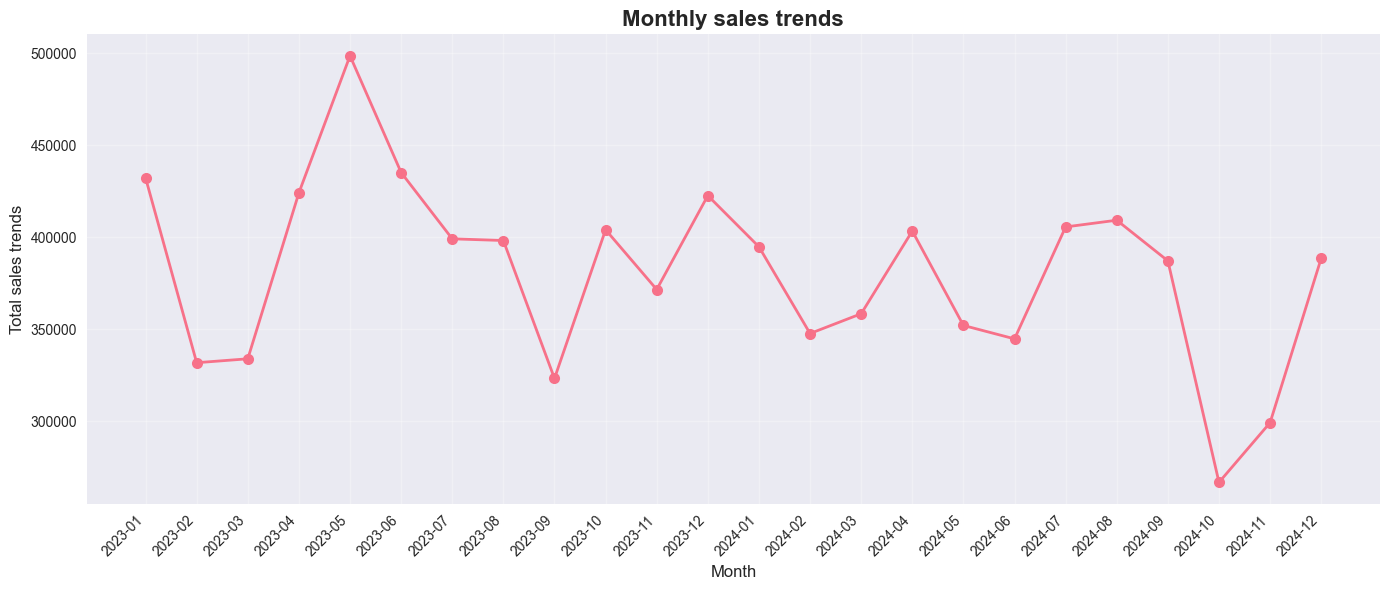

Monthly total sales trend is saved as : monthly_total_sales_trend.png
Quarter sales:
  Quarter_Label  Total_value
0        2023Q1      1098219
1        2023Q2      1358200
2        2023Q3      1120819
3        2023Q4      1198517
4        2024Q1      1101101
5        2024Q2      1100414
6        2024Q3      1202256
7        2024Q4       954753


Average sales by quarters:
Quarter
1    1762.275641
2    1875.372998
3    1849.582006
4    1817.105485
Name: Total_value, dtype: float64


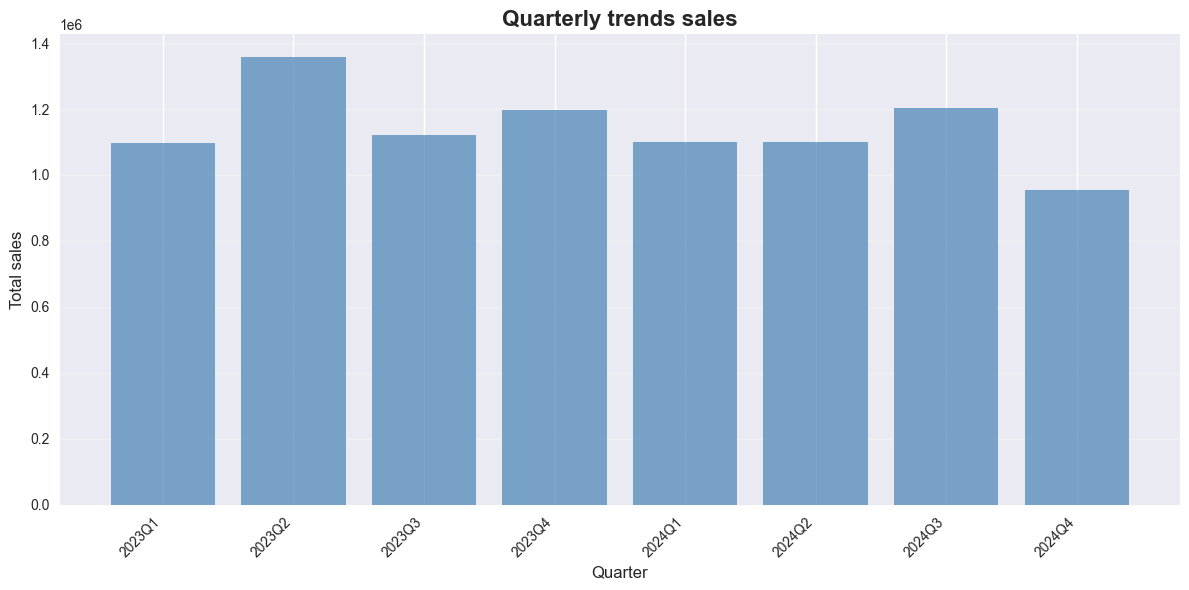

Quarterly trends sales, saved as: quarterly_trends_sales.png
Annual sales:
   Year  Total_value
0  2023      4775755
1  2024      4358524


Annual growth percentage:
   Year  Total_value    Growth
0  2023      4775755       NaN
1  2024      4358524 -8.736441


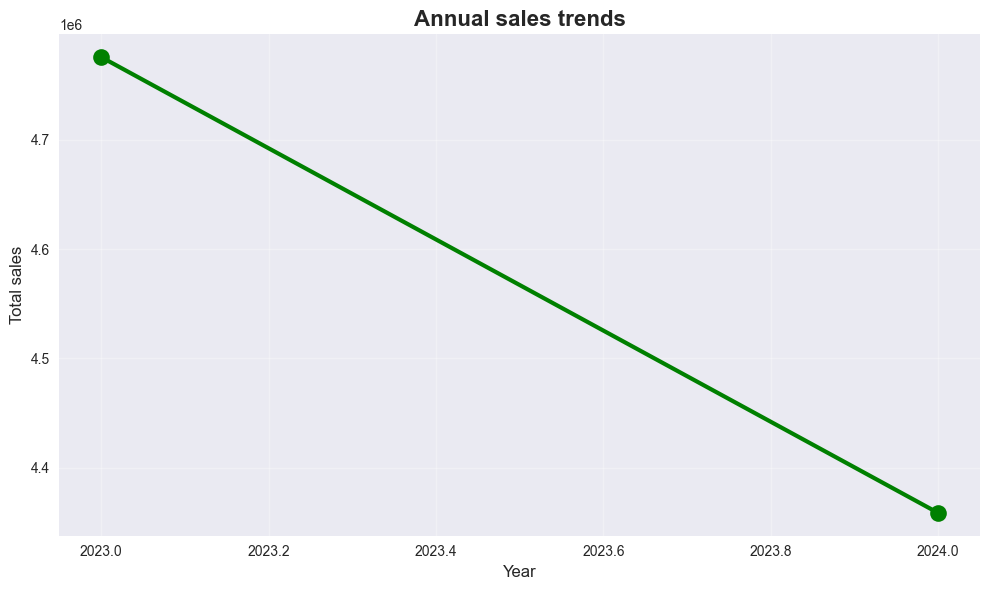

Annual trends sales, saved as: annual_trends_sales.png
Average monthly sales: 380,595
Standard deviation: 50,185
Coeffient of variation: 13.19%


Month with heights volatility: 2023-05
Month with lowest volatility: 2024-09
SEASONAL DECOMPOSITION



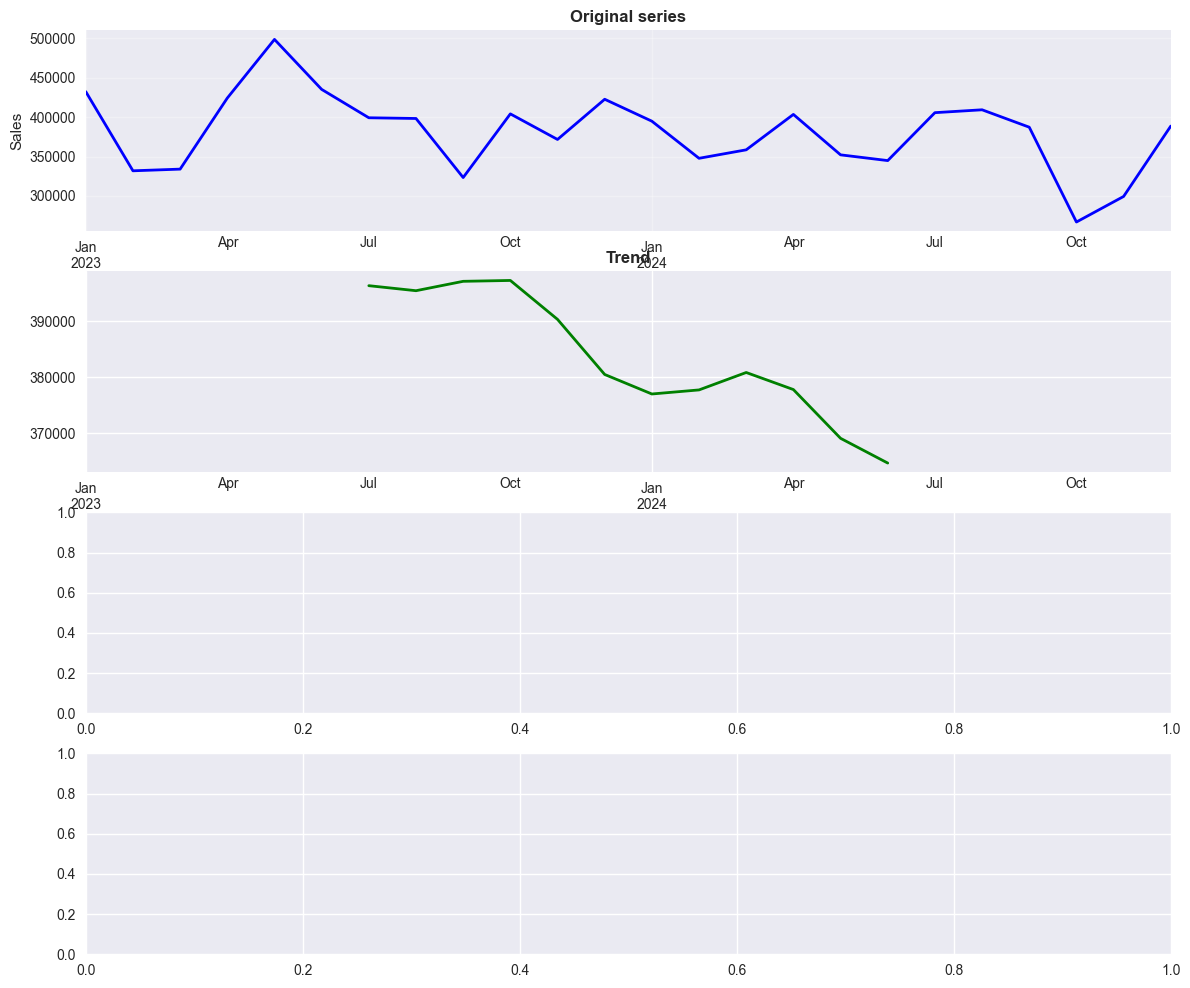

In [5]:
# PHASE 3 - Sales trend analysis

# Monthly sales trends
monthly_sales=df.groupby('Month_Year')['Total_value'].sum().reset_index()
monthly_sales['Month_Year']=monthly_sales['Month_Year'].astype(str)
print('Monthly sales: ')
print(monthly_sales)
print('\n'+ '='*50+'\n')
max_month=monthly_sales.loc[monthly_sales['Total_value'].idxmax()]
min_month=monthly_sales.loc[monthly_sales['Total_value'].idxmin()]
print(f'Month with highest number of sales is {max_month["Month_Year"]}-{max_month["Total_value"]:,.0f} ')
print(f'Month with lowest number of sales is {min_month["Month_Year"]}-{min_month["Total_value"]:,.0f} ')

# Monthly trend visualisation
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Total_value'], marker='o', linewidth=2, markersize=8)
plt.title('Monthly sales trends', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total sales trends', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_total_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Monthly total sales trend is saved as : monthly_total_sales_trend.png')

# Quarter trend sales
quarterly_sales=df.groupby(['Year', 'Quarter'])['Total_value'].sum().reset_index()
quarterly_sales['Quarter_Label']=quarterly_sales['Year'].astype(str)+'Q'+quarterly_sales['Quarter'].astype(str)
print('Quarter sales:')
print(quarterly_sales[['Quarter_Label', 'Total_value']])
print('\n'+ '='*50+'\n')
seasonal_analysis=df.groupby('Quarter')['Total_value'].mean()
print('Average sales by quarters:')
print(seasonal_analysis)

# Quarterly trends visualisation
plt.figure(figsize=(12,6))
plt.bar(quarterly_sales['Quarter_Label'], quarterly_sales['Total_value'], color='steelblue', alpha=0.7)
plt.title('Quarterly trends sales', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('quarterly_trends_sales.png', dpi=300, bbox_inches='tight')
plt.show()
print('Quarterly trends sales, saved as: quarterly_trends_sales.png')

# Annual sales trends
yearly_sales=df.groupby('Year')['Total_value'].sum().reset_index()
print('Annual sales:')
print(yearly_sales)
print('\n'+ '='*50+'\n')
if len(yearly_sales)>1:
    yearly_sales['Growth']=yearly_sales['Total_value'].pct_change()*100
    print('Annual growth percentage:')
    print(yearly_sales[['Year', 'Total_value', 'Growth']])
else:
    print('Data is available for only one year.')


# Annual trends visualisation

if len(yearly_sales)>1:
    plt.figure(figsize=(10,6))
    plt.plot(yearly_sales['Year'], yearly_sales['Total_value'], marker='o', linewidth=3, markersize=12, color='green')
    plt.title('Annual sales trends', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total sales', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('annual_trends_sales.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Annual trends sales, saved as: annual_trends_sales.png')

# Volatility analysis
std_deviation=monthly_sales['Total_value'].std()
mean=monthly_sales['Total_value'].mean()
coefficient_of_variation=(std_deviation/mean)*100
print(f'Average monthly sales: {mean:,.0f}')
print(f'Standard deviation: {std_deviation:,.0f}')
print(f'Coeffient of variation: {coefficient_of_variation:.2f}%')
print('\n'+ '='*50+'\n')
monthly_sales['Deviation']=abs(monthly_sales['Total_value']- mean)
max_volatility=monthly_sales.loc[monthly_sales['Deviation'].idxmax()]
min_volatility=monthly_sales.loc[monthly_sales['Deviation'].idxmin()]
print(f'Month with heights volatility: {max_volatility["Month_Year"]}')
print(f'Month with lowest volatility: {min_volatility["Month_Year"]}')

# Seasonal decomposition
print('='*60)
print('SEASONAL DECOMPOSITION')
print('='*60)
print()

# statsmodels
if STATSMODELS_AVAILABLE:
    time_series_decomp=df.groupby('Month_Year')['Total_value'].sum()
    time_series_decomp.index=pd.to_datetime(time_series_decomp.index.astype(str))
    time_series_decomp=time_series_decomp.sort_index()

    
    # seasonal decomposition
    if len(time_series_decomp)>=12:   # at least 12 months required
        decomposition=seasonal_decompose(time_series_decomp, model='additive',period=12)

        # decomposition visualisation 
        fig,axes=plt.subplots(4,1,figsize=(14,12))

        decomposition.observed.plot(ax=axes[0], color='blue', linewidth=2)
        axes[0].set_title('Original series', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Sales')
        axes[0].grid(True,alpha=0.3)

        decomposition.trend.plot(ax=axes[1], color='green', linewidth=2)
        axes[1].set_title('Trend', fontsize=12, fontweight='bold')
        




    









Monthly sales: 
   Month_Year  Total_value
0     2023-01       432370
1     2023-02       331860
2     2023-03       333989
3     2023-04       424232
4     2023-05       498715
5     2023-06       435253
6     2023-07       399207
7     2023-08       398297
8     2023-09       323315
9     2023-10       404149
10    2023-11       371659
11    2023-12       422709
12    2024-01       394866
13    2024-02       347741
14    2024-03       358494
15    2024-04       403458
16    2024-05       352126
17    2024-06       344830
18    2024-07       405684
19    2024-08       409333
20    2024-09       387239
21    2024-10       266821
22    2024-11       299281
23    2024-12       388651


Month with highest number of sales is 2023-05-498,715 
Month with lowest number of sales is 2024-10-266,821 


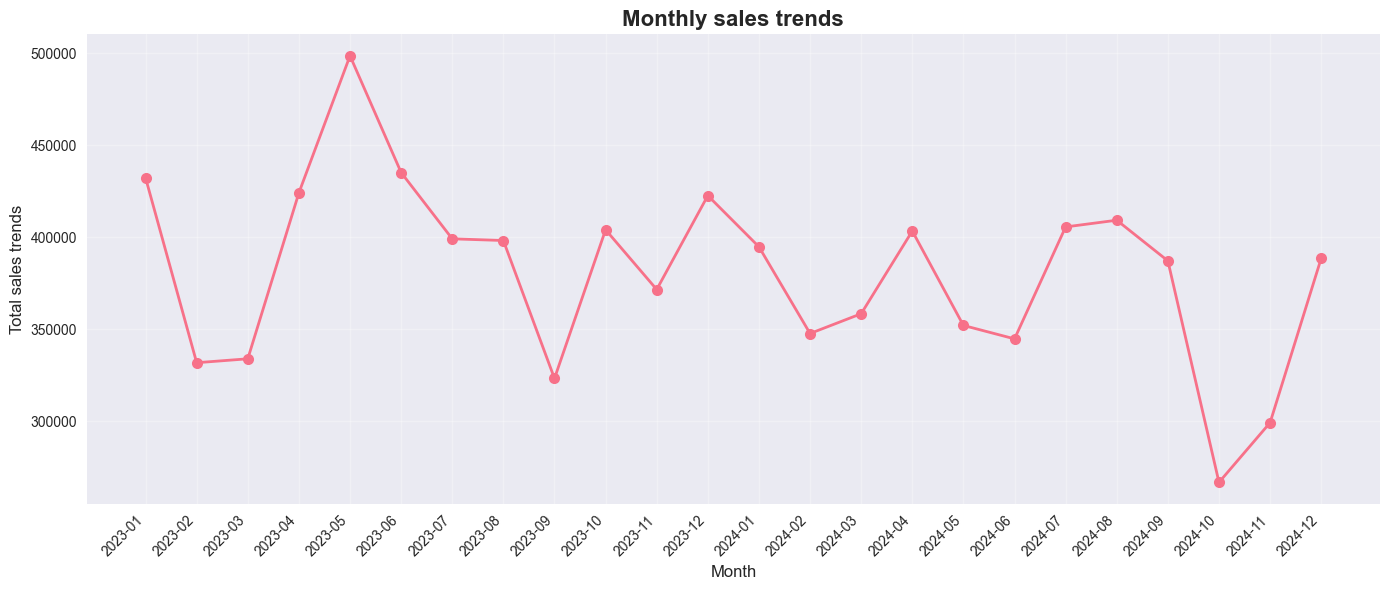

Monthly total sales trend is saved as : monthly_total_sales_trend.png
Quarter sales:
  Quarter_Label  Total_value
0        2023Q1      1098219
1        2023Q2      1358200
2        2023Q3      1120819
3        2023Q4      1198517
4        2024Q1      1101101
5        2024Q2      1100414
6        2024Q3      1202256
7        2024Q4       954753


Average sales by quarters:
Quarter
1    1762.275641
2    1875.372998
3    1849.582006
4    1817.105485
Name: Total_value, dtype: float64


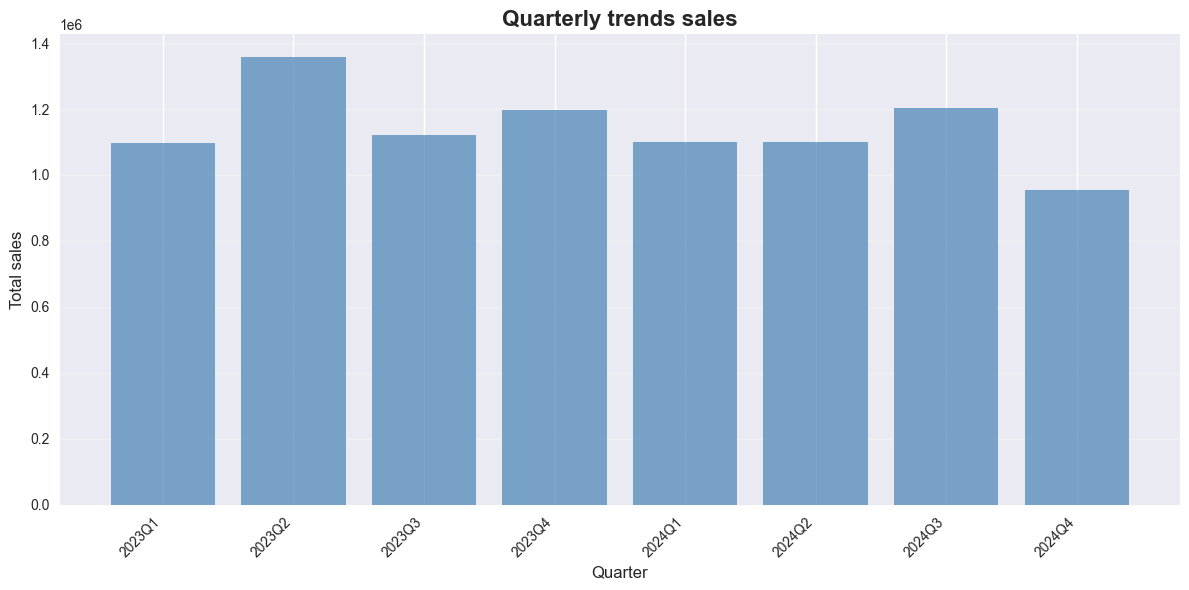

Quarterly trends sales, saved as: quarterly_trends_sales.png
Annual sales:
   Year  Total_value
0  2023      4775755
1  2024      4358524


Annual growth percentage:
   Year  Total_value    Growth
0  2023      4775755       NaN
1  2024      4358524 -8.736441


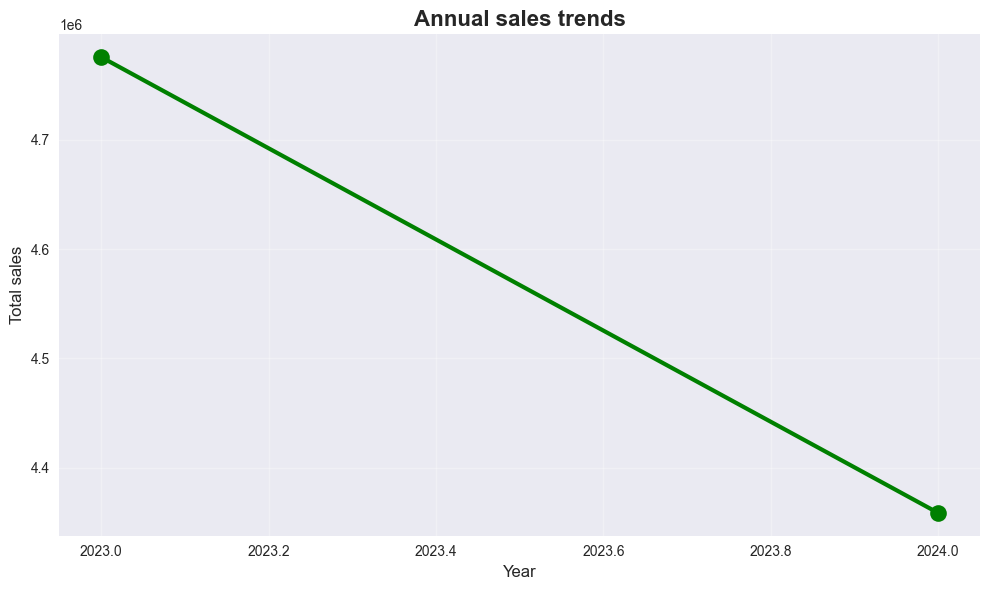

Annual trends sales, saved as: annual_trends_sales.png
Average monthly sales: 380,595
Standard deviation: 50,185
Coeffient of variation: 13.19%


Month with heights volatility: 2023-05
Month with lowest volatility: 2024-09
SEASONAL DECOMPOSITION



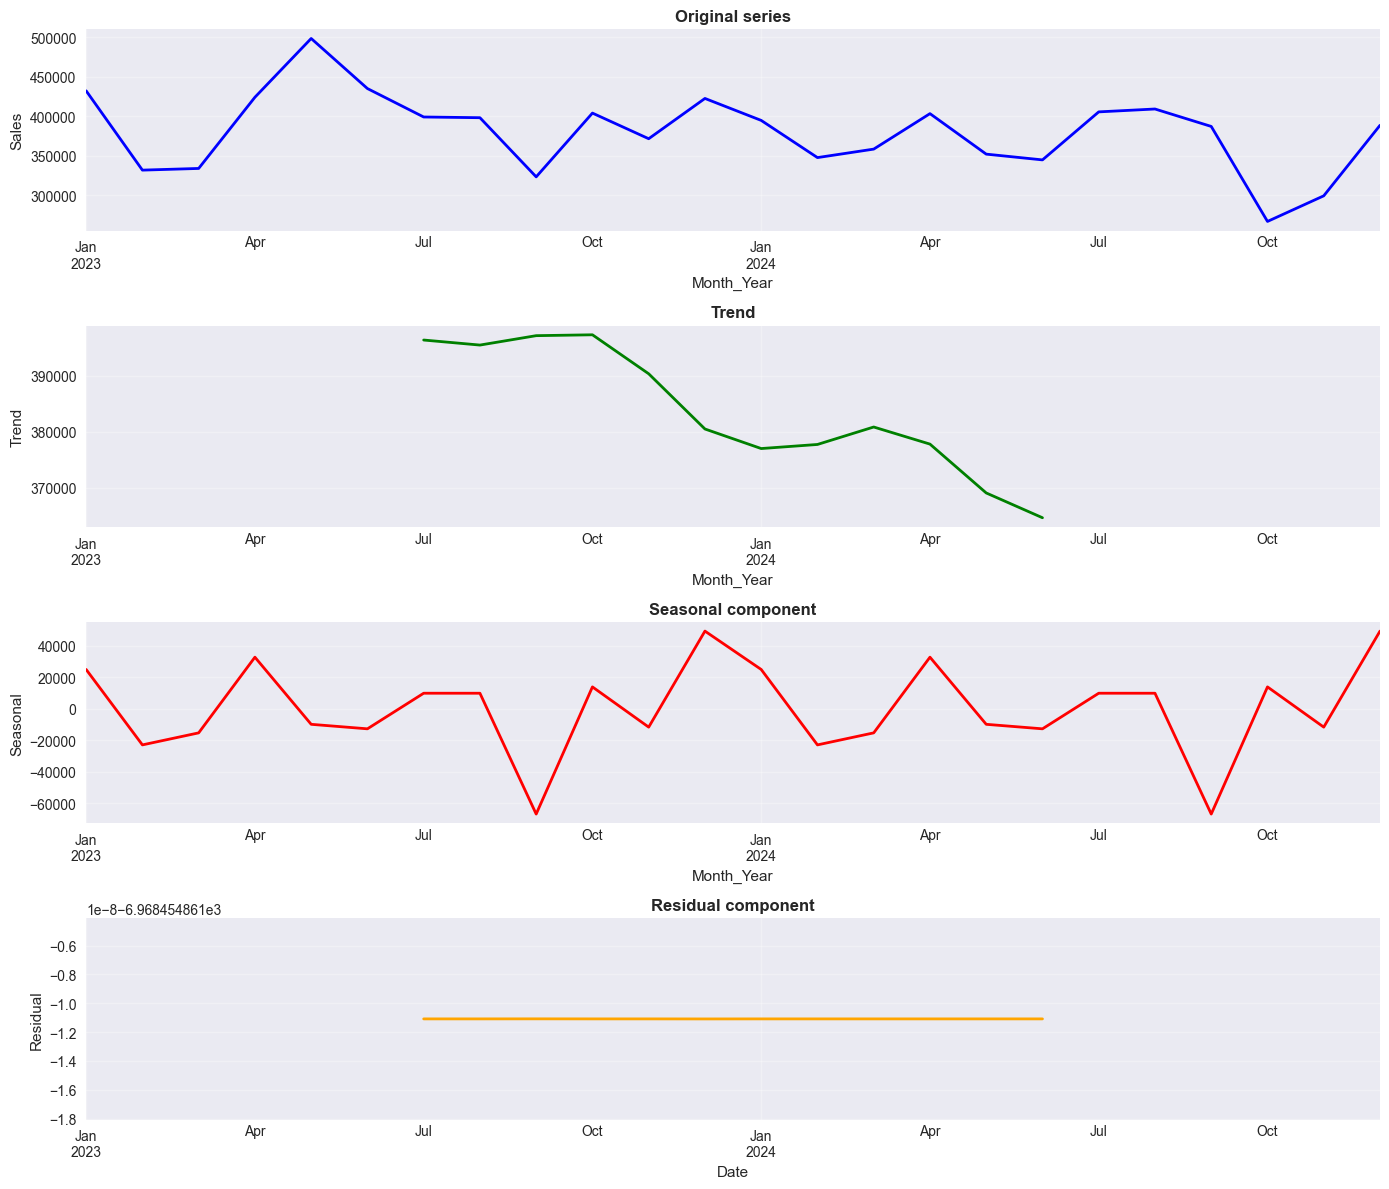

Seasonal decomposition saved as : seasonal_decomposition.png
Seasonal strength: 0.5913
Strong seasonal component


In [6]:
# PHASE 3 - Sales trend analysis

# Monthly sales trends
monthly_sales=df.groupby('Month_Year')['Total_value'].sum().reset_index()
monthly_sales['Month_Year']=monthly_sales['Month_Year'].astype(str)
print('Monthly sales: ')
print(monthly_sales)
print('\n'+ '='*50+'\n')
max_month=monthly_sales.loc[monthly_sales['Total_value'].idxmax()]
min_month=monthly_sales.loc[monthly_sales['Total_value'].idxmin()]
print(f'Month with highest number of sales is {max_month["Month_Year"]}-{max_month["Total_value"]:,.0f} ')
print(f'Month with lowest number of sales is {min_month["Month_Year"]}-{min_month["Total_value"]:,.0f} ')

# Monthly trend visualisation
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Total_value'], marker='o', linewidth=2, markersize=8)
plt.title('Monthly sales trends', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total sales trends', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_total_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Monthly total sales trend is saved as : monthly_total_sales_trend.png')

# Quarter trend sales
quarterly_sales=df.groupby(['Year', 'Quarter'])['Total_value'].sum().reset_index()
quarterly_sales['Quarter_Label']=quarterly_sales['Year'].astype(str)+'Q'+quarterly_sales['Quarter'].astype(str)
print('Quarter sales:')
print(quarterly_sales[['Quarter_Label', 'Total_value']])
print('\n'+ '='*50+'\n')
seasonal_analysis=df.groupby('Quarter')['Total_value'].mean()
print('Average sales by quarters:')
print(seasonal_analysis)

# Quarterly trends visualisation
plt.figure(figsize=(12,6))
plt.bar(quarterly_sales['Quarter_Label'], quarterly_sales['Total_value'], color='steelblue', alpha=0.7)
plt.title('Quarterly trends sales', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('quarterly_trends_sales.png', dpi=300, bbox_inches='tight')
plt.show()
print('Quarterly trends sales, saved as: quarterly_trends_sales.png')

# Annual sales trends
yearly_sales=df.groupby('Year')['Total_value'].sum().reset_index()
print('Annual sales:')
print(yearly_sales)
print('\n'+ '='*50+'\n')
if len(yearly_sales)>1:
    yearly_sales['Growth']=yearly_sales['Total_value'].pct_change()*100
    print('Annual growth percentage:')
    print(yearly_sales[['Year', 'Total_value', 'Growth']])
else:
    print('Data is available for only one year.')


# Annual trends visualisation

if len(yearly_sales)>1:
    plt.figure(figsize=(10,6))
    plt.plot(yearly_sales['Year'], yearly_sales['Total_value'], marker='o', linewidth=3, markersize=12, color='green')
    plt.title('Annual sales trends', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total sales', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('annual_trends_sales.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Annual trends sales, saved as: annual_trends_sales.png')

# Volatility analysis
std_deviation=monthly_sales['Total_value'].std()
mean=monthly_sales['Total_value'].mean()
coefficient_of_variation=(std_deviation/mean)*100
print(f'Average monthly sales: {mean:,.0f}')
print(f'Standard deviation: {std_deviation:,.0f}')
print(f'Coeffient of variation: {coefficient_of_variation:.2f}%')
print('\n'+ '='*50+'\n')
monthly_sales['Deviation']=abs(monthly_sales['Total_value']- mean)
max_volatility=monthly_sales.loc[monthly_sales['Deviation'].idxmax()]
min_volatility=monthly_sales.loc[monthly_sales['Deviation'].idxmin()]
print(f'Month with heights volatility: {max_volatility["Month_Year"]}')
print(f'Month with lowest volatility: {min_volatility["Month_Year"]}')

# Seasonal decomposition
print('='*60)
print('SEASONAL DECOMPOSITION')
print('='*60)
print()

# statsmodels
if STATSMODELS_AVAILABLE:
    time_series_decomp=df.groupby('Month_Year')['Total_value'].sum()
    time_series_decomp.index=pd.to_datetime(time_series_decomp.index.astype(str))
    time_series_decomp=time_series_decomp.sort_index()

    
    # seasonal decomposition
    if len(time_series_decomp)>=12:  # at least 12 months required
        decomposition=seasonal_decompose(time_series_decomp, model='additive',period=12)

        # decomposition visualisation 
        fig,axes=plt.subplots(4,1,figsize=(14,12))

        decomposition.observed.plot(ax=axes[0], color='blue', linewidth=2)
        axes[0].set_title('Original series', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Sales')
        axes[0].grid(True,alpha=0.3)

        decomposition.trend.plot(ax=axes[1], color='green', linewidth=2)
        axes[1].set_title('Trend', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Trend')
        axes[1].grid(True,alpha=0.3)

        decomposition.seasonal.plot(ax=axes[2], color='red', linewidth=2)
        axes[2].set_title('Seasonal component', fontsize=12, fontweight='bold')
        axes[2].set_ylabel('Seasonal')
        axes[2].grid(True,alpha=0.3)

        decomposition.resid.plot(ax=axes[3], color='orange', linewidth=2)
        axes[3].set_title('Residual component', fontsize=12, fontweight='bold')
        axes[3].set_ylabel('Residual')
        axes[3].set_xlabel('Date')
        axes[3].grid(True,alpha=0.3)

        plt.tight_layout()
        plt.savefig('seasonal_decomposition.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Seasonal decomposition saved as : seasonal_decomposition.png')

        # seasonality analysis
        seasonal_strength=decomposition.seasonal.std()/decomposition.observed.std()
        print(f'Seasonal strength: {seasonal_strength:.4f}')
        if seasonal_strength>0.5:
            print('Strong seasonal component')
        elif seasonal_strength>0.2:
            print('Moderate seasonal component')
        else: 
            print('Weak seasonal component')
    else: 
        print('Insufficient data for seasonal decomposition (at least 12 months required)')
else:
    print('Statsmodels not available. Skipping seasonal decomposition.')
    






    

        


        




    









Profit by products:
         Product  Profit
5         Laptop  751774
1   Graphic Card  634884
10     Processor  373559
6        Monitor  286858
12           SSD  200571
7    Motherboard  197827
3     Headphones  133697
2      Hard disc  117985
11    RAM memory  107289
4       Keyboard   90702
14    Web Camera   81903
9   Power Supply   78450
8          Mouse   60704
0           Case   60143
13     USB drive   35981


Top 10 the most profitable products:
         Product  Profit
5         Laptop  751774
1   Graphic Card  634884
10     Processor  373559
6        Monitor  286858
12           SSD  200571
7    Motherboard  197827
3     Headphones  133697
2      Hard disc  117985
11    RAM memory  107289
4       Keyboard   90702


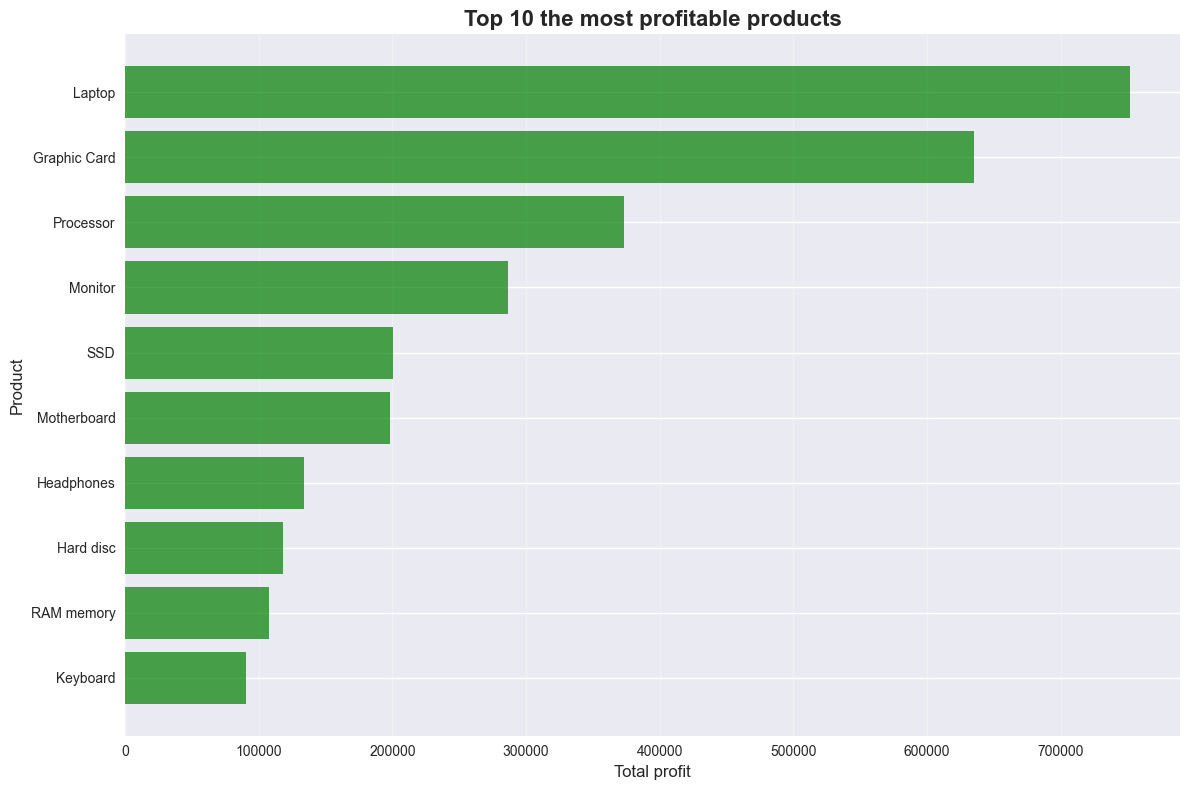

Profit by categories:
      Category   Profit
0   Components  1739010
1    Computers   751774
3  Peripherals   367006
2    Equipment   354537


Profit percentage by categories:
      Category   Profit  Percentage
0   Components  1739010   54.135522
1    Computers   751774   23.402786
3  Peripherals   367006   11.424927
2    Equipment   354537   11.036766


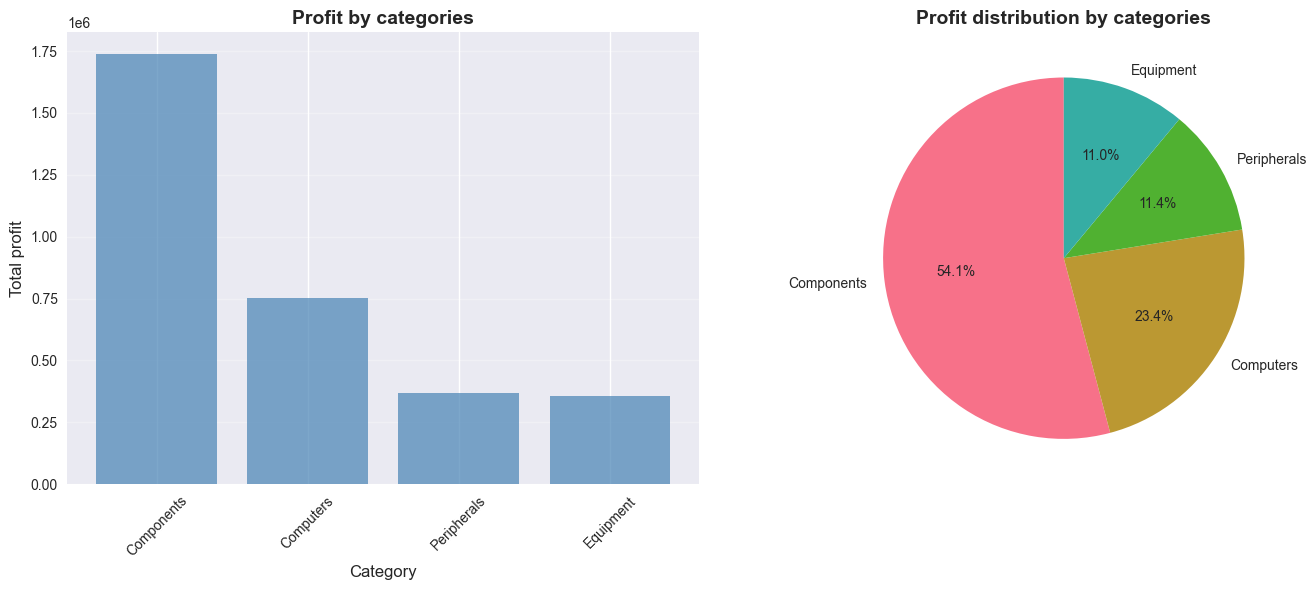

Average profit margin by products:
         Product  Profit_Margin
13     USB drive      36.514894
0           Case      35.908732
8          Mouse      35.719412
4       Keyboard      35.664488
2      Hard disc      35.459109
9   Power Supply      35.353383
3     Headphones      35.332701
7    Motherboard      35.294804
11    RAM memory      35.259125
1   Graphic Card      35.196388
12           SSD      35.134273
6        Monitor      35.070258
5         Laptop      35.063436
14    Web Camera      34.990515
10     Processor      34.793019


Average profit margin by categories:
      Category  Profit_Margin
2    Equipment      35.691190
3  Peripherals      35.434421
0   Components      35.278159
1    Computers      35.063436


Product with the highest profit margin: USB drive-36.51%
Product with the lowest profit margin: Processor-34.79%
Relationship between sales quantity and profit by products:
         Product  Quantity  Profit
5         Laptop      1744  751774
1   Graphic Card   

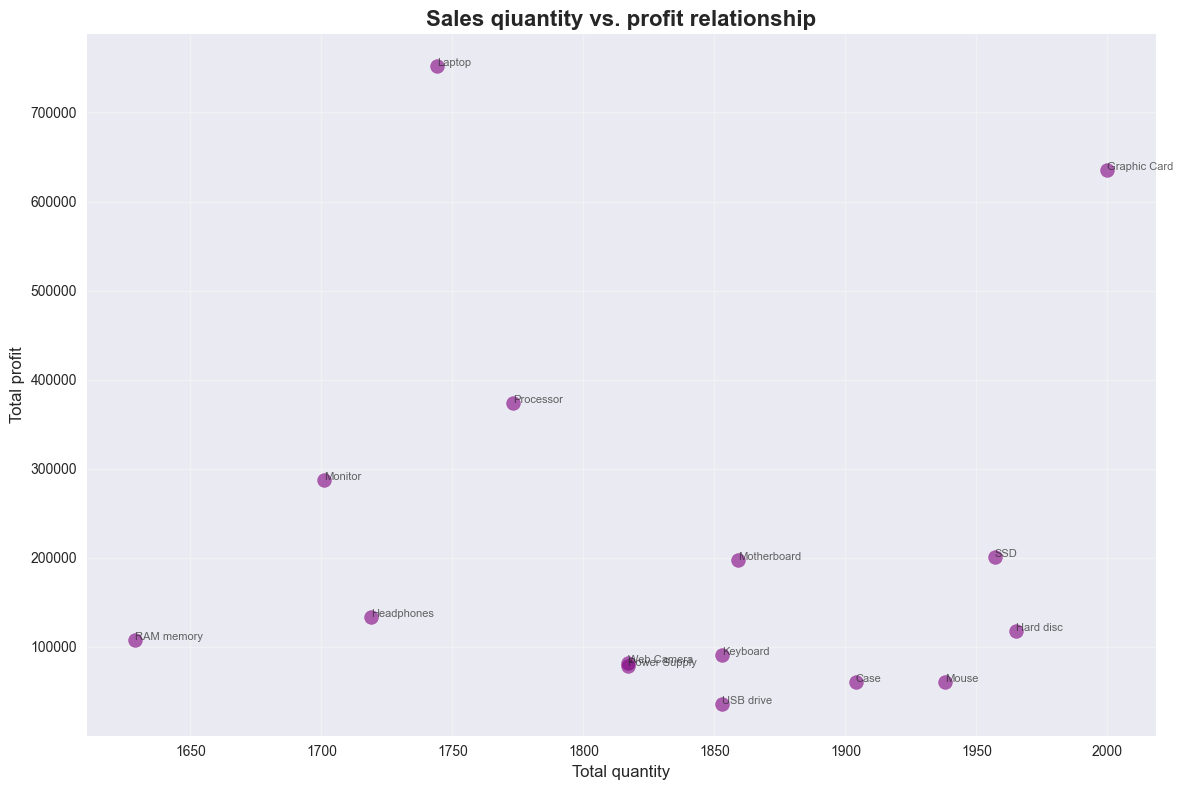

CORRELATION ANALYSIS

Corrrelation matrix: 
                Quantity  Price_per_unit  Total_value  Costs  Profit  \
Quantity           1.000          -0.012        0.377  0.376   0.376   
Price_per_unit    -0.012           1.000        0.815  0.815   0.810   
Total_value        0.377           0.815        1.000  0.998   0.995   
Costs              0.376           0.815        0.998  1.000   0.988   
Profit             0.376           0.810        0.995  0.988   1.000   
Profit_Margin      0.022          -0.081       -0.056 -0.089   0.004   

                Profit_Margin  
Quantity                0.022  
Price_per_unit         -0.081  
Total_value            -0.056  
Costs                  -0.089  
Profit                  0.004  
Profit_Margin           1.000  



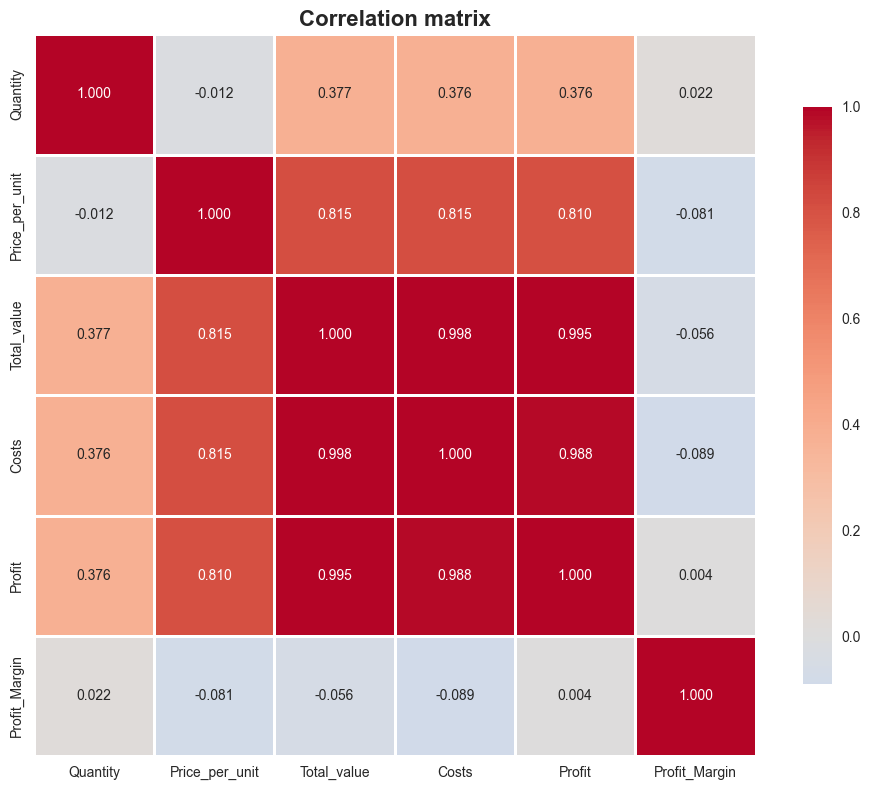

Correlation matrix is saved as: correlation_matrix.png
The strongest correlations (|r|>0.5): 
       Variable_1   Variable_2  Correlation
3     Total_value        Costs     0.998482
4     Total_value       Profit     0.994860
5           Costs       Profit     0.987772
0  Price_per_unit  Total_value     0.815478
1  Price_per_unit        Costs     0.814911
2  Price_per_unit       Profit     0.810054
ABC/XYZ PRODUCT CLASSIFICATION

ABC/XYZ product classification
ABC_XYZ
AZ    6
BZ    5
CZ    4
dtype: int64



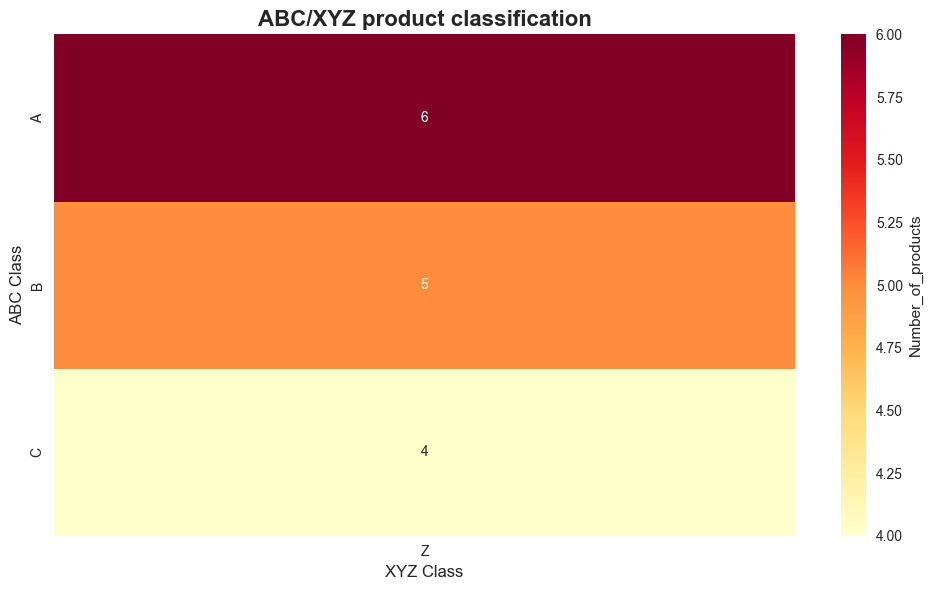

ABC/XYZ classification is saved as: abc_xyz_classification.png
ABC/XYZ Classification exported to csv
STATISTICAL TESTS

T-test for profit between Peripheralsand Components:
T-statistic: -20.5016
P-value 0.0000
There is a statistically significant difference (p<0.05)

Shapiro Wilk test for profit distribution normality:
Statistic: 0.6628
P-value: 0.0000
Distribution is not normal

PRODUCT CLUSTERING ANALYSIS



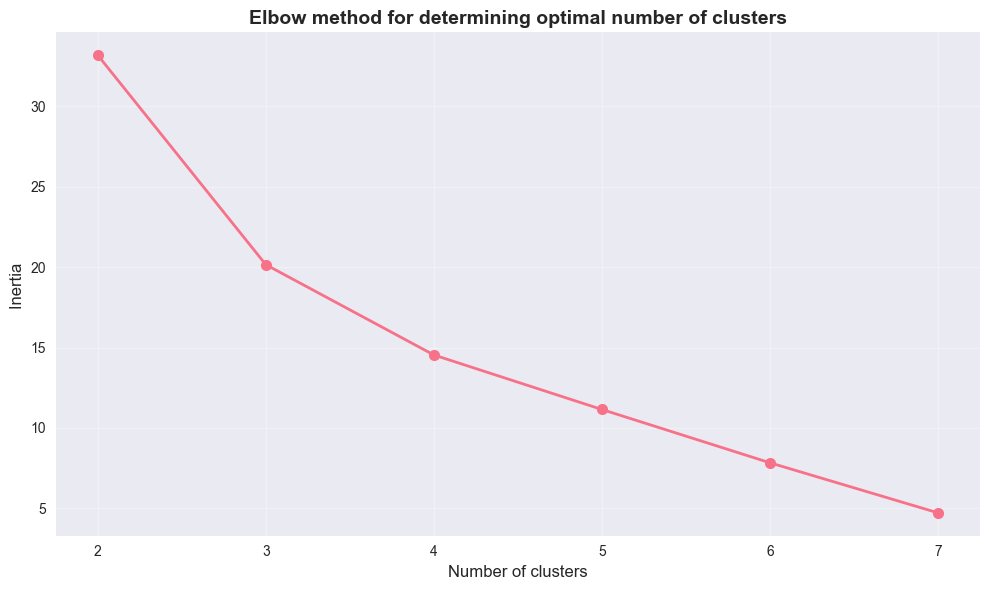

Products classificated in 3 clusters:
         Product  Total_value     Profit  Profit_Margin
Cluster                                                
0              2    1969639.0  693329.00          35.13
1              8     520776.5  182519.25          35.15
2              5     205757.8   73103.00          35.85



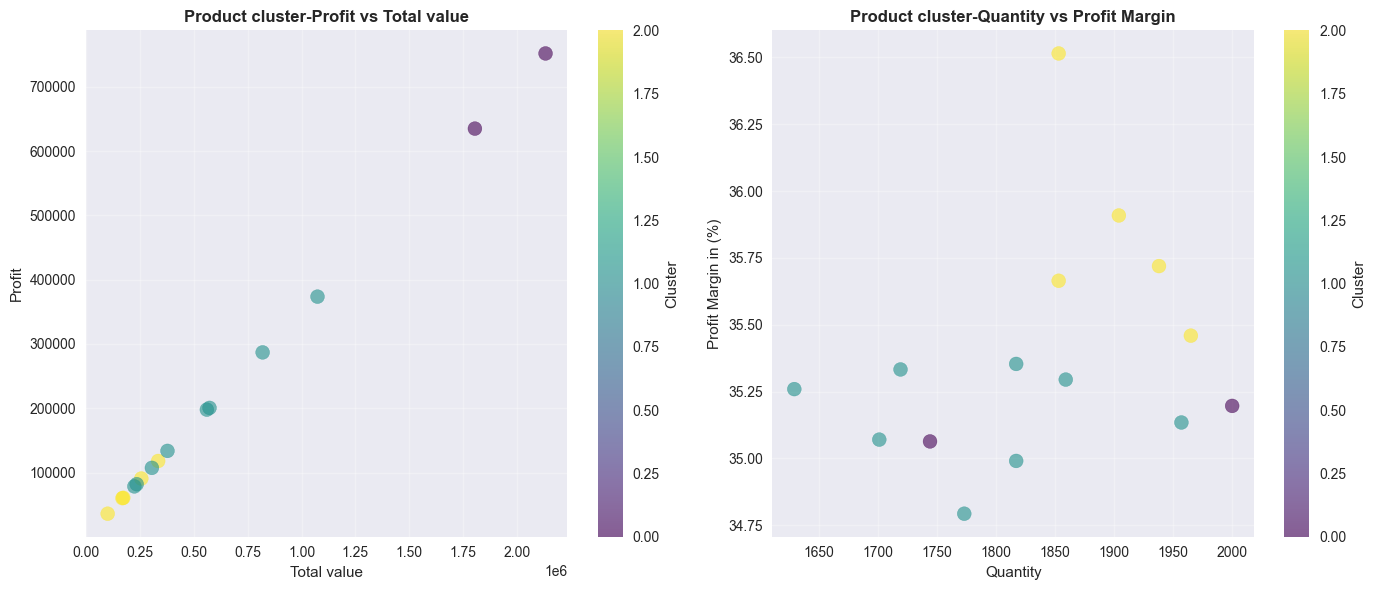

Clustering analysis is saved as: products_clusters.png
Product clusters are exported to csv file.


In [14]:
# PHASE 4 - Product and category profitability analysis

# profitability analysis by products
profit_by_product=df.groupby('Product')['Profit'].sum().reset_index()
profit_by_product=profit_by_product.sort_values('Profit', ascending=False)
print('Profit by products:')
print(profit_by_product)
print('\n'+ '='*50+'\n')
top_10_products=profit_by_product.head(10)
print('Top 10 the most profitable products:')
print(top_10_products)

# top 10 the most profitable products visualisation
plt.figure(figsize=(12,8))
plt.barh(top_10_products['Product'], top_10_products['Profit'], color='green', alpha=0.7)
plt.title('Top 10 the most profitable products', fontsize=16, fontweight='bold')
plt.xlabel('Total profit', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# profitability analysis by categories
profit_by_category=df.groupby('Category')['Profit'].sum().reset_index()
profit_by_category=profit_by_category.sort_values('Profit', ascending=False)
print('Profit by categories:')
print(profit_by_category)
print('\n'+ '='*50+'\n')
total_profit=profit_by_category['Profit'].sum()
profit_by_category['Percentage']=(profit_by_category['Profit']/total_profit)*100
print('Profit percentage by categories:')
print(profit_by_category[['Category', 'Profit', 'Percentage']])


# profit by categories visualisation
fig,(ax1, ax2)=plt.subplots(1,2, figsize=(14,6))
ax1.bar(profit_by_category['Category'], profit_by_category['Profit'], color='steelblue', alpha=0.7)
ax1.set_title('Profit by categories', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Total profit', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
ax2.pie(profit_by_category['Profit'], labels=profit_by_category['Category'], autopct='%1.1f%%', startangle=90)
ax2.set_title('Profit distribution by categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Profit margin analysis
profit_margin_products=df.groupby('Product')['Profit_Margin'].mean().reset_index()
profit_margin_products=profit_margin_products.sort_values('Profit_Margin', ascending=False)
print('Average profit margin by products:')
print(profit_margin_products)
print('\n'+ '='*50+'\n')
profit_margin_categories=df.groupby('Category')['Profit_Margin'].mean().reset_index()
profit_margin_categories=profit_margin_categories.sort_values('Profit_Margin', ascending=False)
print('Average profit margin by categories:')
print(profit_margin_categories)
print('\n'+ '='*50+'\n')
print(f'Product with the highest profit margin: {profit_margin_products.iloc[0]["Product"]}-{profit_margin_products.iloc[0]["Profit_Margin"]:.2f}%')
print(f'Product with the lowest profit margin: {profit_margin_products.iloc[-1]["Product"]}-{profit_margin_products.iloc[-1]["Profit_Margin"]:.2f}%')

# Sales quantity vs profit analysis 
quantity_profit=df.groupby('Product').agg({
    'Quantity':'sum', 
    'Profit':'sum'
}).reset_index()
print('Relationship between sales quantity and profit by products:')
print(quantity_profit.sort_values('Profit', ascending=False))
print('\n'+ '='*50+'\n')
quantity_profit['Profit_per_unit']=quantity_profit['Profit']/quantity_profit['Quantity']
high_sales_low_profit=quantity_profit[(quantity_profit['Quantity']>quantity_profit['Quantity'].median())&(quantity_profit['Profit_per_unit']<quantity_profit['Profit_per_unit'].median())]
print("Products with high sales, but lowest profit per unit: ")
print(high_sales_low_profit[['Product','Quantity','Profit', 'Profit_per_unit']])

## scatter plot- quantity vs. profit relationship
plt.figure(figsize=(12,8))
plt.scatter(quantity_profit['Quantity'], quantity_profit['Profit'], s=100, alpha=0.6, color='purple')
plt.title('Sales qiuantity vs. profit relationship', fontsize=16, fontweight='bold')
plt.xlabel('Total quantity', fontsize=12)
plt.ylabel('Total profit', fontsize=12)
plt.grid(True, alpha=0.3)
for idx, row in quantity_profit.iterrows():
    plt.annotate(row['Product'], (row['Quantity'], row['Profit']), fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()


# Correlation analysis
print('='*60)
print('CORRELATION ANALYSIS')
print('='*60)
print()

# Calculation correlation matrix

correlation_columns=['Quantity', 'Price_per_unit', 'Total_value', 'Costs', 'Profit', 'Profit_Margin']
correlation_matrix=df[correlation_columns].corr()

print("Corrrelation matrix: ")
print(correlation_matrix.round(3))
print()

# Correlation matrix visualisation

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={'shrink':0.8})
plt.title('Correlation matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation matrix is saved as: correlation_matrix.png")


# Identifying the strongest correlations
correlation_values=[]
for i in range(len(correlation_columns)):
    for j in range(i+1, len(correlation_columns)):
        correlation=correlation_matrix.iloc[i,j]
        if abs(correlation)>0.5:
            correlation_values.append({
                'Variable_1': correlation_columns[i],
                'Variable_2': correlation_columns[j],
                'Correlation': correlation
            })
if correlation_values:
    correlations_df=pd.DataFrame(correlation_values).sort_values('Correlation', key=abs, ascending=False)
    print('The strongest correlations (|r|>0.5): ')
    print(correlations_df)

# ABC/XYZ product classification

print('='*60)
print('ABC/XYZ PRODUCT CLASSIFICATION')
print('='*60)
print()

# ABC Analysis - by sales value
products_abc=df.groupby('Product')['Total_value'].sum().reset_index()
products_abc=products_abc.sort_values('Total_value', ascending=False)
products_abc['Cumulative_percentage']= (products_abc['Total_value'].cumsum()/products_abc['Total_value'].sum())*100

def classify_abc(cumulative_percentage):
    if cumulative_percentage<=80:
        return 'A'
    elif cumulative_percentage<=95:
        return 'B'
    else:
        return 'C'


products_abc['ABC_Class']=products_abc['Cumulative_percentage'].apply(classify_abc)

# xyz analysis - variability sales
products_xyz=df.groupby('Product')['Total_value'].agg(['mean', 'std']).reset_index()
products_xyz['Coefficient_of_variation']=(products_xyz['std']/products_xyz['mean'])*100
products_xyz['Coefficient_of_variation']=products_xyz['Coefficient_of_variation'].fillna(0)

def classify_xyz(cv):
    if cv<=25:
        return 'X'
    elif cv<=50:
        return 'Y'
    else: 
        return 'Z'

products_xyz['XYZ_Class']=products_xyz['Coefficient_of_variation'].apply(classify_xyz)

# combination classification ABC/XYZ
abc_xyz=pd.merge(products_abc[['Product', 'ABC_Class']], 
                products_xyz[['Product', 'XYZ_Class']], 
                on='Product')
abc_xyz['ABC_XYZ']=abc_xyz['ABC_Class']+abc_xyz['XYZ_Class']

print('ABC/XYZ product classification')
print(abc_xyz.groupby('ABC_XYZ').size().sort_values(ascending=False))
print()

# ABC/XYZ classification visualisation
abc_xyz_pivot=abc_xyz.groupby(['ABC_Class', 'XYZ_Class']).size().reset_index(name='Number_of_products')
abc_xyz_pivot=abc_xyz_pivot.pivot(index='ABC_Class',columns='XYZ_Class', values='Number_of_products').fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(abc_xyz_pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label':'Number_of_products'})
plt.title('ABC/XYZ product classification', fontsize=16, fontweight='bold')
plt.xlabel('XYZ Class', fontsize=12)
plt.ylabel('ABC Class', fontsize=12)
plt.tight_layout()
plt.savefig('abc_xyz_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print('ABC/XYZ classification is saved as: abc_xyz_classification.png')

# Export ABC/XYZ classification into csv file

abc_xyz.to_csv('results_abc_xyz_classification.csv', index=False, encoding='utf-8-sig')
print('ABC/XYZ Classification exported to csv')

# Statistical tests
print('='*120)
print('STATISTICAL TESTS')
print('='*120)
print()

# T-test for comparing profit between categories

categories_list=df['Category'].unique()
if len(categories_list)>=2:
    category1=df[df['Category']==categories_list[0]]['Profit']
    category2=df[df['Category']==categories_list[1]]['Profit']

    t_stat, p_value=stats.ttest_ind(category1, category2)
    print(f'T-test for profit between {categories_list[0]}and {categories_list[1]}:')
    print(f'T-statistic: {t_stat:.4f}')
    print(f'P-value {p_value:.4f}')
    if p_value<0.05:
        print('There is a statistically significant difference (p<0.05)')
    else: 
        print('There is no statistically significant difference (p>=0.05)')
    print()


# Shapiro-Wilk test for profit distribution normality
shapiro_stat, shapiro_p= stats.shapiro(df['Profit'].sample(min(5000,len(df))))
print('Shapiro Wilk test for profit distribution normality:')
print(f'Statistic: {shapiro_stat:.4f}')
print(f'P-value: {shapiro_p:.4f}')
if shapiro_p< 0.05: 
    print('Distribution is not normal')
else:
    print('Distribution is normal')
print()


# Product clustering analysis
print('='*120)
print('PRODUCT CLUSTERING ANALYSIS')
print('='*120)
print()

# Preparing the data for clastering
products_cluster=df.groupby('Product').agg({
    'Total_value': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum', 
    'Profit_Margin': 'mean'
}).reset_index()

# Data standardisation
scaler=StandardScaler()
products_cluster_scaled=scaler.fit_transform(products_cluster[['Total_value', 'Profit', 'Quantity', 'Profit_Margin']])

# Determinig optimal number of clusters (elbow method)
inertias=[]
K_range=range(2,min(8,len(products_cluster)))
for k in K_range:
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(products_cluster_scaled)
    inertias.append(kmeans.inertia_)

# Elbow method of visualization
plt.figure(figsize=(10,6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.title('Elbow method for determining optimal number of clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Inertia ', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Clustering with optimal number of clusters(3)
optimal_k=3
kmeans=KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
products_cluster['Cluster']=kmeans.fit_predict(products_cluster_scaled) 

print(f'Products classificated in {optimal_k} clusters:')
print(products_cluster.groupby('Cluster').agg({
    'Product': 'count',
    'Total_value': 'mean',
    'Profit': 'mean',
    'Profit_Margin': 'mean'
}).round(2))
print()

# Cluster visualisation
fig, axes=plt.subplots(1,2,figsize=(14,6))

# Scatter plot - Profit vs Total value
scatter1=axes[0].scatter(products_cluster['Total_value'], products_cluster['Profit'], c=products_cluster['Cluster'], cmap='viridis', s=100, alpha=0.6)
axes[0].set_title('Product cluster-Profit vs Total value', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total value')
axes[0].set_ylabel('Profit')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Scatter plot - Quantity vs Profit Margin
scatter2=axes[1].scatter(products_cluster['Quantity'], products_cluster['Profit_Margin'],c=products_cluster['Cluster'],cmap='viridis',s=100,alpha=0.6)
axes[1].set_title('Product cluster-Quantity vs Profit Margin', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Profit Margin in (%)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# Graphics for both scatter plots
plt.tight_layout()
plt.savefig('products_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print('Clustering analysis is saved as: products_clusters.png')

# Export clusters
products_cluster.to_csv('results_products_cluster.csv', index=False, encoding='utf-8-sig')
print('Product clusters are exported to csv file.')














